In [2]:
import numpy as np 
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt 
import pandas as pd

In [84]:
tau = pd.read_csv("tau_data.csv")["Actual Tau?"].to_numpy()
N = pd.read_csv("tau_data.csv")["Coincident Counts"].to_numpy() * 1000

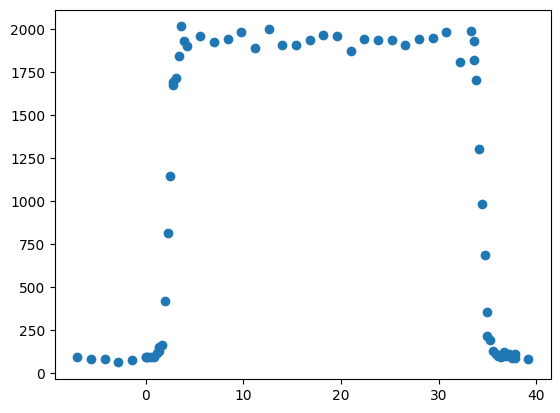

In [85]:
plt.scatter(tau, N)

In [91]:
def smooth_step(x, tau, delta, A, b, k=10.0):
    left  = 1.0 / (1.0 + np.exp(-k * (x - (tau - delta))))
    right = 1.0 / (1.0 + np.exp(-k * (x - (tau + delta))))
    return b + A * (left - right)

In [97]:
p0 = [15, 18, 2 * 1000, 0.05 * 1000, 100]
mu, X = curve_fit(smooth_step, tau, N,
                 bounds = ([8, 10, 0.01 * 1000, 0.01 * 1000, 1],[25, 25, 3 * 1000, 0.25 * 1000, 100]),
                 p0 = p0,
                 sigma = np.sqrt(N))

/var/folders/v9/czyc2p85057bkq0_b7k6tp2r0000gn/T/ipykernel_91361/3502345319.py:3: RuntimeWarning: overflow encountered in exp
  right = 1.0 / (1.0 + np.exp(-k * (x - (tau + delta))))


<ErrorbarContainer object of 3 artists>

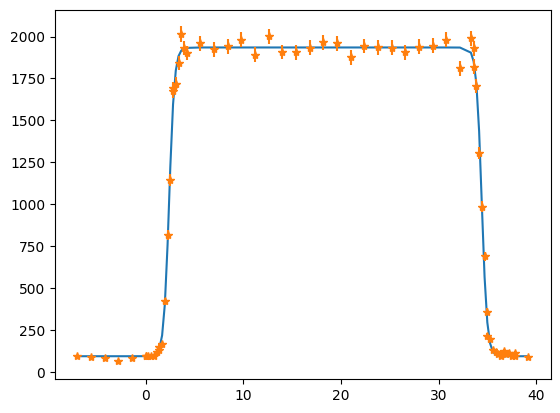

In [105]:
plt.plot(tau, smooth_step(tau, *mu))
plt.errorbar(tau, N, np.sqrt(N), marker = "*", ls = "None")

In [95]:
mu

array([  18.41258281,   16.01734805, 1841.38357062,   93.32161303,
          3.67214497])

In [96]:
np.sqrt(np.diag(X)) 

array([1.22681008e-02, 1.55342968e-02, 1.59316790e+01, 3.70154312e+00,
       1.32535777e-01])